In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk.util import ngrams
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk.util import ngrams


import os


In [2]:
# ---  Load and Inspect Data ---
print("---  Loading and Inspecting Data ---")
df = pd.read_csv('nurse_emotion.csv')

print("\nFirst 5 rows of the dataset:")
print(df.head())

---  Loading and Inspecting Data ---

First 5 rows of the dataset:
  patientid  age  gender           observationStart  \
0     P0035   87    Male  2025-06-01T00:00:00+10:00   
1     P0035   87    Male  2025-06-01T06:00:00+10:00   
2     P0035   87    Male  2025-06-01T12:00:00+10:00   
3     P0035   87    Male  2025-06-01T18:00:00+10:00   
4     P0036   72  Female  2025-06-01T00:00:00+10:00   

              observationEnd  \
0  2025-06-01T06:00:00+10:00   
1  2025-06-01T12:00:00+10:00   
2  2025-06-01T18:00:00+10:00   
3  2025-06-02T00:00:00+10:00   
4  2025-06-01T06:00:00+10:00   

                                         nursingNote   medications  heartRate  \
0  Patient slept without disturbance and remained...           NaN         75   
1  Patient appeared withdrawn and tearful; emotio...    Lisinopril         80   
2  Patient was settled and cooperative during rou...    Lisinopril         91   
3  Patient expressed concern; HR 96 and BP 146/64...  Atorvastatin         96   
4  P

In [3]:
print("\nDataset Information (columns, data types, non-null counts):")
df.info()


Dataset Information (columns, data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patientid           448 non-null    object 
 1   age                 448 non-null    int64  
 2   gender              448 non-null    object 
 3   observationStart    448 non-null    object 
 4   observationEnd      448 non-null    object 
 5   nursingNote         448 non-null    object 
 6   medications         344 non-null    object 
 7   heartRate           448 non-null    int64  
 8   spo2                448 non-null    int64  
 9   temperature         448 non-null    float64
 10  bloodPressure       448 non-null    int64  
 11  stepsTaken          448 non-null    int64  
 12  calorieIntake       448 non-null    int64  
 13  sleepHours          448 non-null    float64
 14  waterIntakeMl       448 non-null    int64  
 

In [4]:
# ---  Data Cleaning ---
print("\n--- : Data Cleaning ---")
print("\nMissing values per column before cleaning:")
print(df.isnull().sum())


--- : Data Cleaning ---

Missing values per column before cleaning:
patientid               0
age                     0
gender                  0
observationStart        0
observationEnd          0
nursingNote             0
medications           104
heartRate               0
spo2                    0
temperature             0
bloodPressure           0
stepsTaken              0
calorieIntake           0
sleepHours              0
waterIntakeMl           0
mealsSkipped            0
exerciseMinutes         0
bathroomVisits        448
behaviourTags         448
emotionTags             0
clinicalSummary       448
entitiesExtracted     448
baselineStats         448
alerts                448
state                 448
emotionpolarity         0
adls.sleep_minutes      0
dose                  104
dtype: int64


In [5]:
# Drop columns that are completely empty
df.dropna(axis=1, how='all', inplace=True)
print("\nMissing values after dropping empty columns:")
print(df.isnull().sum())
print("\nEmpty columns have been removed.")



Missing values after dropping empty columns:
patientid               0
age                     0
gender                  0
observationStart        0
observationEnd          0
nursingNote             0
medications           104
heartRate               0
spo2                    0
temperature             0
bloodPressure           0
stepsTaken              0
calorieIntake           0
sleepHours              0
waterIntakeMl           0
mealsSkipped            0
exerciseMinutes         0
emotionTags             0
emotionpolarity         0
adls.sleep_minutes      0
dose                  104
dtype: int64

Empty columns have been removed.



---  Analyzing the Target Variable ---
Generated 'emotion_polarity_distribution.png' to show the target variable balance.


/tmp/ipykernel_405475/1424761092.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='emotionpolarity', data=df, palette='viridis')


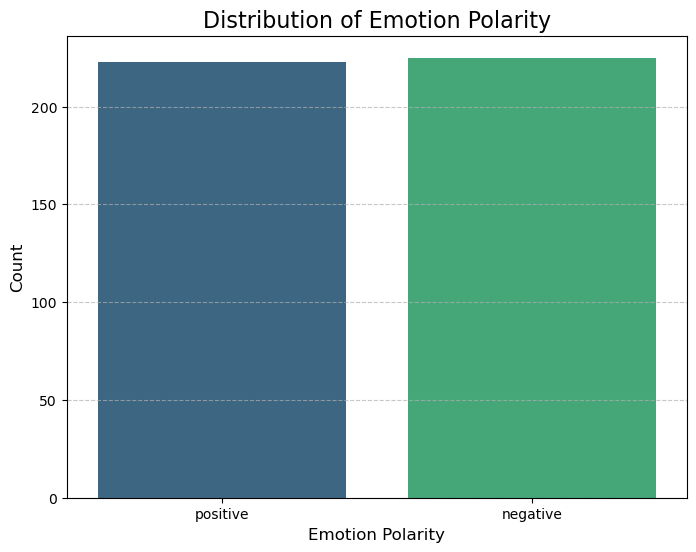

In [6]:
# ---  Analyze the Target Variable (emotionpolarity) ---
print("\n---  Analyzing the Target Variable ---")
plt.figure(figsize=(8, 6))
sns.countplot(x='emotionpolarity', data=df, palette='viridis')
plt.title('Distribution of Emotion Polarity', fontsize=16)
plt.xlabel('Emotion Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('emotion_polarity_distribution.png')
print("Generated 'emotion_polarity_distribution.png' to show the target variable balance.")


In [7]:
df['emotionpolarity'].value_counts()

emotionpolarity
negative    225
positive    223
Name: count, dtype: int64


---  Analyzing Key Features ---
Generated 'gender_distribution.png' for gender distribution.


/tmp/ipykernel_405475/1590082724.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='pastel')


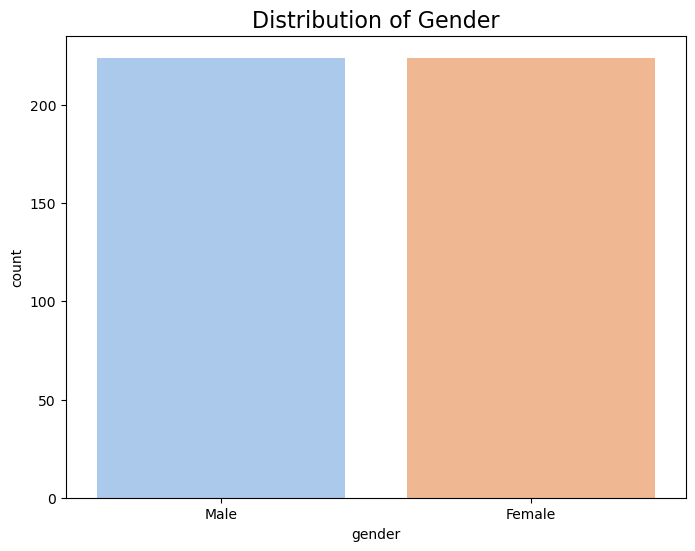

In [8]:
# ---  Analyze Key Features ---
print("\n---  Analyzing Key Features ---")
# Gender Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', data=df, palette='pastel')
plt.title('Distribution of Gender', fontsize=16)
plt.savefig('gender_distribution.png')
print("Generated 'gender_distribution.png' for gender distribution.")

Generated 'age_distribution.png' for age distribution.


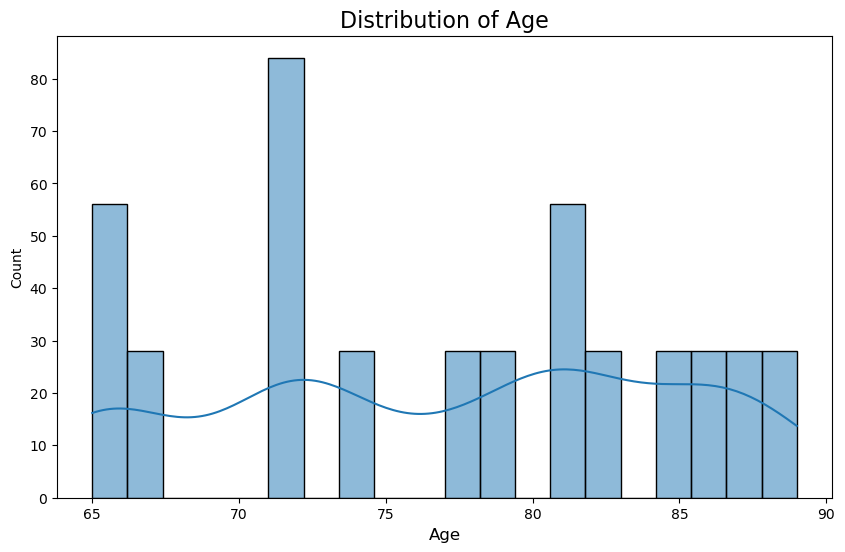

In [9]:
# Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Age', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.savefig('age_distribution.png')
print("Generated 'age_distribution.png' for age distribution.")


---  Exploring Text Data ---
Generated 'note_length_distribution.png' to analyze note length.
Generated 'wordcloud_positive.png' and 'wordcloud_negative.png' to visualize common words.


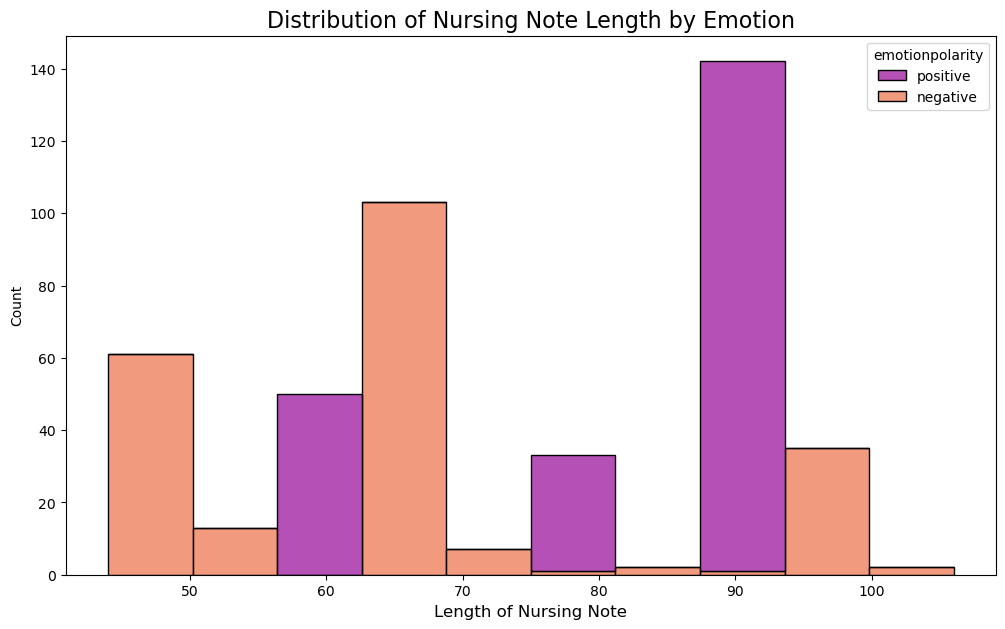

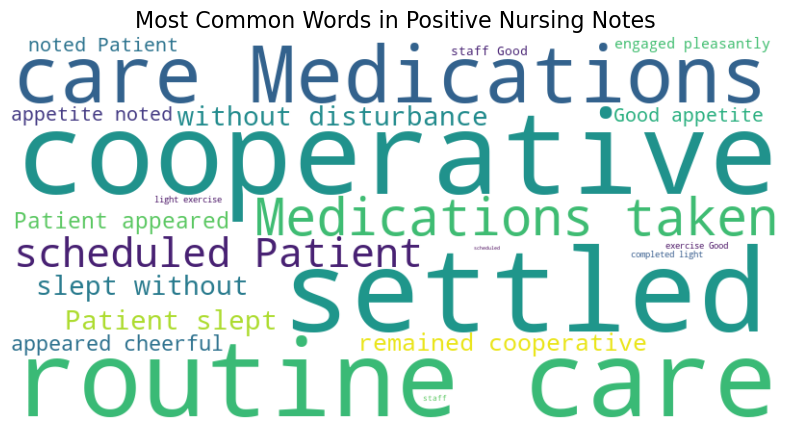

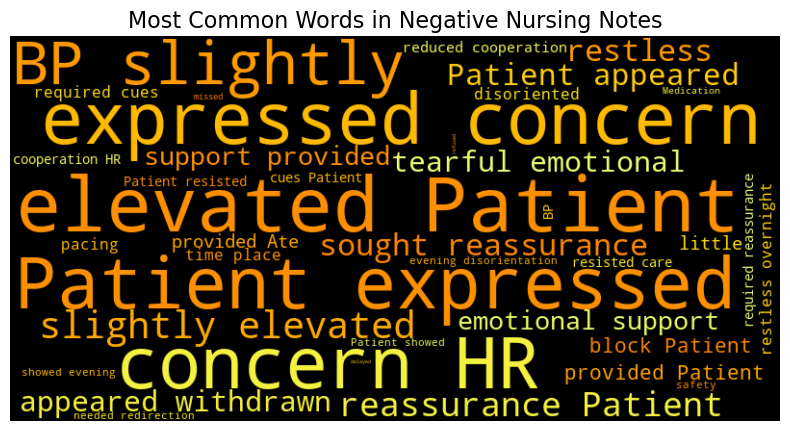

In [10]:
# ---  Explore the Text Data (nursingNote) ---
print("\n---  Exploring Text Data ---")
# Create a feature for the length of the nursing note
df['note_length'] = df['nursingNote'].str.len()

# Plot the distribution of note length by emotion polarity
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='note_length', hue='emotionpolarity', multiple='stack', palette='plasma')
plt.title('Distribution of Nursing Note Length by Emotion', fontsize=16)
plt.xlabel('Length of Nursing Note', fontsize=12)
plt.savefig('note_length_distribution.png')
print("Generated 'note_length_distribution.png' to analyze note length.")

# Generate Word Clouds
positive_text = ' '.join(df[df['emotionpolarity'] == 'positive']['nursingNote'])
negative_text = ' '.join(df[df['emotionpolarity'] == 'negative']['nursingNote'])

positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Wistia').generate(negative_text)

# Plot Positive Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Nursing Notes', fontsize=16)
plt.savefig('wordcloud_positive.png')

# Plot Negative Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Nursing Notes', fontsize=16)
plt.savefig('wordcloud_negative.png')
print("Generated 'wordcloud_positive.png' and 'wordcloud_negative.png' to visualize common words.")




---  Bivariate Analysis (Finding Relationships) ---
Generated 'age_vs_emotion.png' to see relationship between age and emotion.


/tmp/ipykernel_405475/2302326974.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='emotionpolarity', y='age', data=df, palette='coolwarm')


Generated 'correlation_heatmap.png' for numerical feature correlations.

EDA script finished successfully!


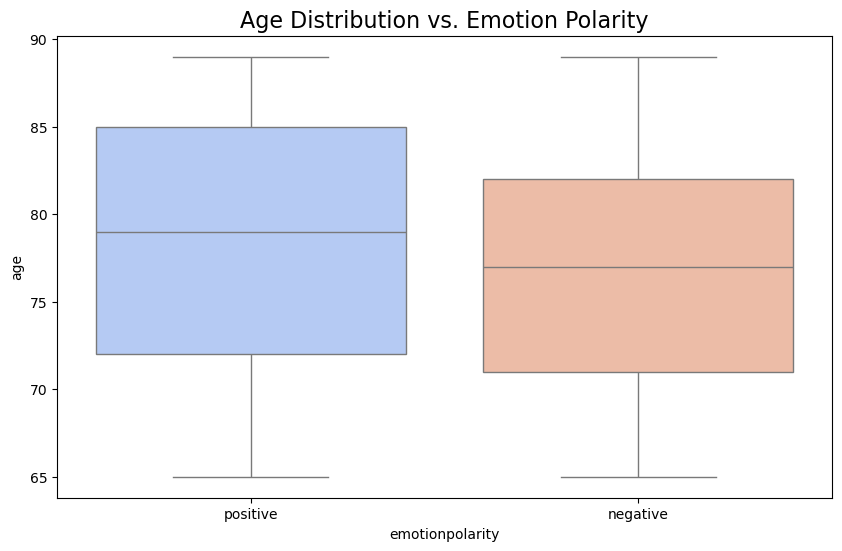

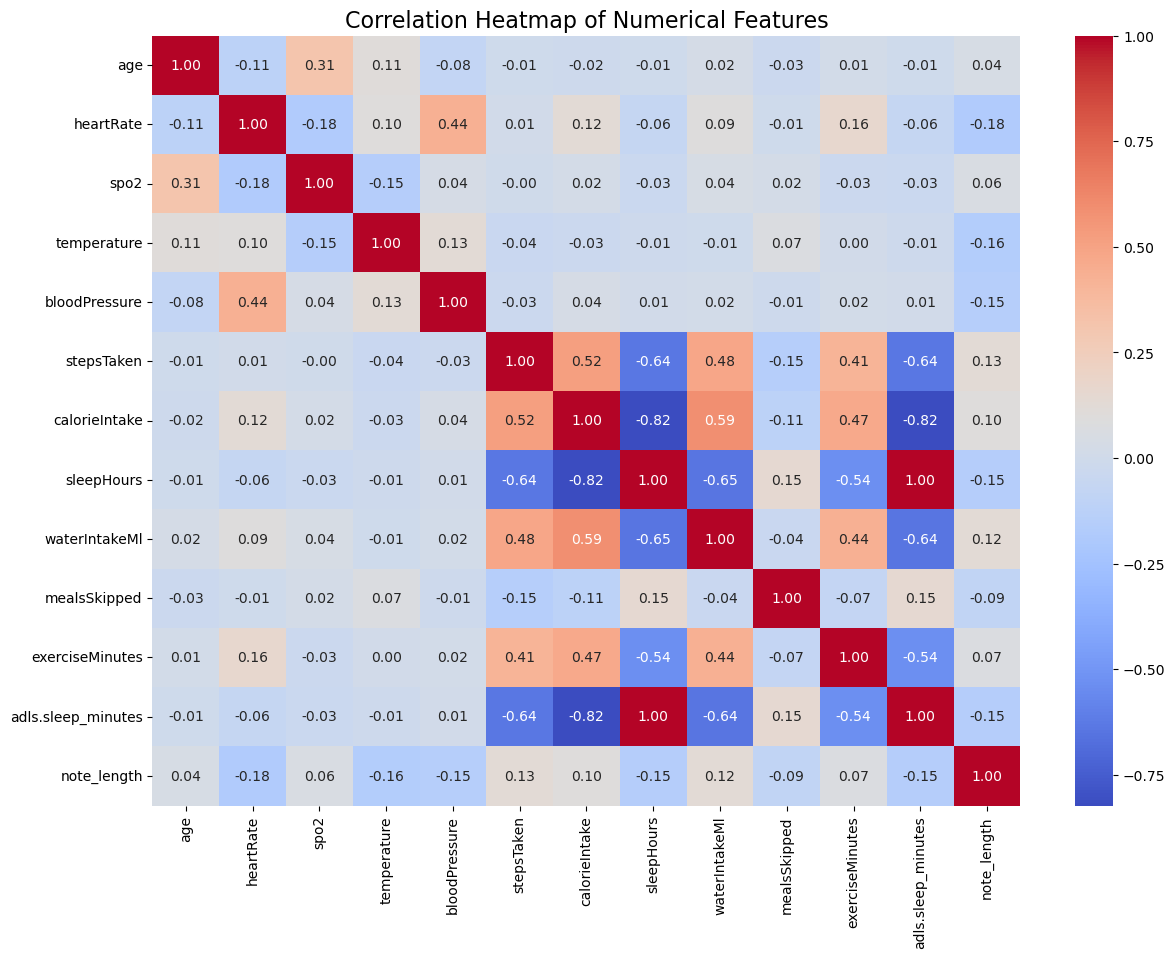

In [11]:
# ---  Bivariate Analysis ---
print("\n---  Bivariate Analysis (Finding Relationships) ---")
# Age vs. Emotion Polarity
plt.figure(figsize=(10, 6))
sns.boxplot(x='emotionpolarity', y='age', data=df, palette='coolwarm')
plt.title('Age Distribution vs. Emotion Polarity', fontsize=16)
plt.savefig('age_vs_emotion.png')
print("Generated 'age_vs_emotion.png' to see relationship between age and emotion.")

# Correlation Heatmap for numerical features
plt.figure(figsize=(14, 10))
numerical_cols = df.select_dtypes(include=['number'])
sns.heatmap(numerical_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.savefig('correlation_heatmap.png')
print("Generated 'correlation_heatmap.png' for numerical feature correlations.")

print("\nEDA script finished successfully!")

In [12]:
# --- Download NLTK data (only need to run once) ---
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/unix_david/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/unix_david/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
# ---  Text Preprocessing ---
print("\n---  Text Preprocessing ---")
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove punctuation and numbers
    text = re.sub('[^a-zA-Z]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize
    text = text.split()
    # Lemmatize and remove stop words
    text = [lemmatizer.lemmatize(word) for word in text if not word in stop_words]
    text = ' '.join(text)
    return text

# Apply the cleaning function to the nursing notes
df['cleaned_note'] = df['nursingNote'].apply(clean_text)

print("\nExample of original vs. cleaned nursing note:")
print("Original: ", df['nursingNote'][1])
print("Cleaned:  ", df['cleaned_note'][1])


print("\n--- Pipeline Ready for Model Training ---")


---  Text Preprocessing ---

Example of original vs. cleaned nursing note:
Original:  Patient appeared withdrawn and tearful; emotional support provided.
Cleaned:   patient appeared withdrawn tearful emotional support provided

--- Pipeline Ready for Model Training ---



---  Deeper Data Profiling ---

---  Profiling the Text Column ---
Average length of entries (in words): 7.16
Generated 'word_count_distribution.png' for word count distribution.

Top 10 most common bigrams:
[(('patient', 'settled'), 141), (('settled', 'cooperative'), 141), (('cooperative', 'routine'), 141), (('routine', 'care'), 141), (('care', 'medication'), 141), (('medication', 'taken'), 141), (('taken', 'scheduled'), 141), (('scheduled', 'patient'), 141), (('hr', 'bp'), 89), (('patient', 'appeared'), 87)]

Top 10 most common trigrams:
[(('patient', 'settled', 'cooperative'), 141), (('settled', 'cooperative', 'routine'), 141), (('cooperative', 'routine', 'care'), 141), (('routine', 'care', 'medication'), 141), (('care', 'medication', 'taken'), 141), (('medication', 'taken', 'scheduled'), 141), (('taken', 'scheduled', 'patient'), 141), (('patient', 'expressed', 'concern'), 76), (('expressed', 'concern', 'hr'), 76), (('concern', 'hr', 'bp'), 76)]


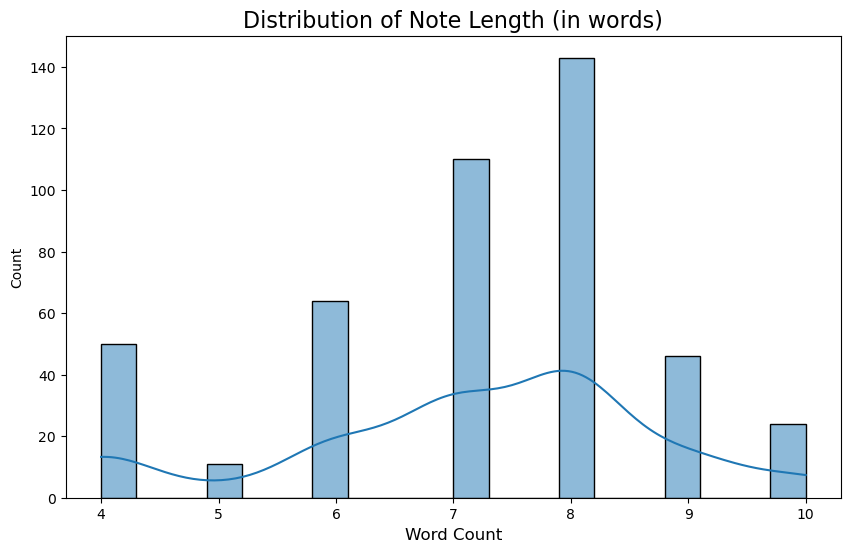

In [14]:
# ---  Deeper Data Profiling ---
print("\n---  Deeper Data Profiling ---")

# --- 8.1 Profile your text column ---
print("\n---  Profiling the Text Column ---")
df['word_count'] = df['cleaned_note'].apply(lambda x: len(x.split()))
avg_word_count = df['word_count'].mean()
print(f"Average length of entries (in words): {avg_word_count:.2f}")

# Distribution of entry lengths
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', bins=20, kde=True)
plt.title('Distribution of Note Length (in words)', fontsize=16)
plt.xlabel('Word Count', fontsize=12)
plt.savefig('word_count_distribution.png')
print("Generated 'word_count_distribution.png' for word count distribution.")

# Common n-grams
all_words = ' '.join(df['cleaned_note']).split()
# Bigrams
common_bigrams = Counter(ngrams(all_words, 2)).most_common(10)
print("\nTop 10 most common bigrams:")
print(common_bigrams)
# Trigrams
common_trigrams = Counter(ngrams(all_words, 3)).most_common(10)
print("\nTop 10 most common trigrams:")
print(common_trigrams)



---  Profiling Emotion Labels ---
Generated 'emotion_tags_distribution.png' for specific emotion tags.

Class distribution of emotionTags:
emotionTags
Calm        185
Worried     127
Sad          49
Happy        38
Agitated     27
Confused     22
Name: count, dtype: int64

Note: Each entry appears to have a single emotion tag, not multiple labels.


/tmp/ipykernel_405475/479370261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='emotionTags', data=df, order=df['emotionTags'].value_counts().index, palette='magma')


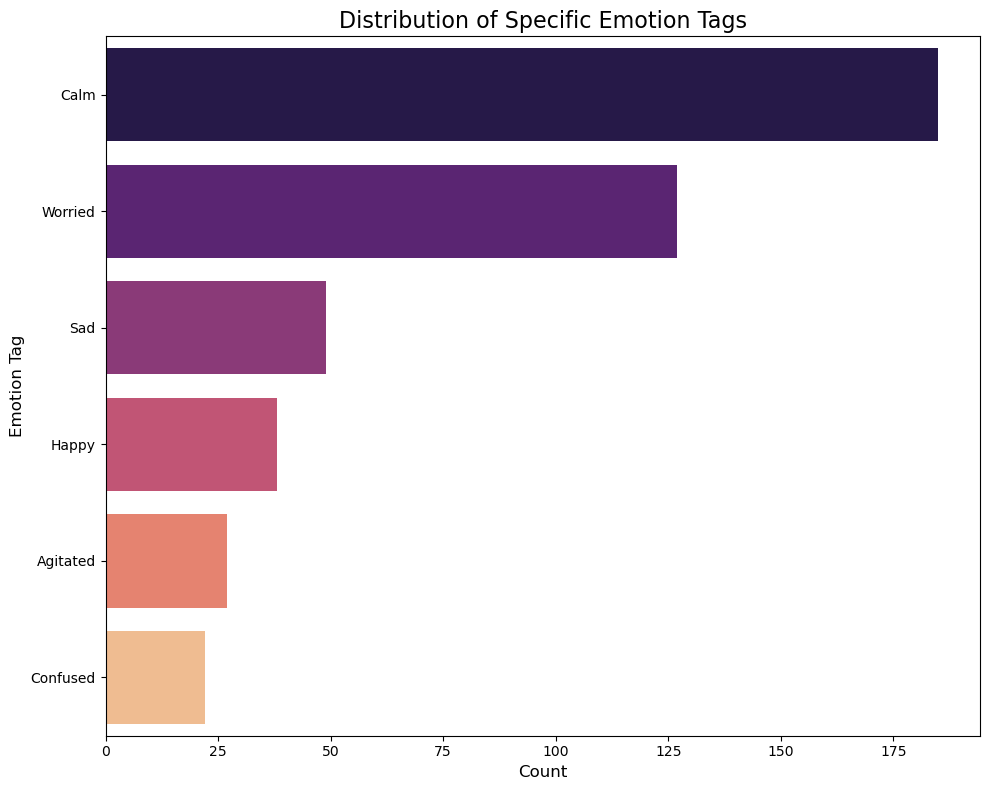

In [15]:


# --- Profile  emotion labels ---
print("\n---  Profiling Emotion Labels ---")
# Using the more granular 'emotionTags' column
plt.figure(figsize=(10, 8))
sns.countplot(y='emotionTags', data=df, order=df['emotionTags'].value_counts().index, palette='magma')
plt.title('Distribution of Specific Emotion Tags', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Emotion Tag', fontsize=12)
plt.tight_layout()
plt.savefig('emotion_tags_distribution.png')
print("Generated 'emotion_tags_distribution.png' for specific emotion tags.")
print("\nClass distribution of emotionTags:")
print(df['emotionTags'].value_counts())
print("\nNote: Each entry appears to have a single emotion tag, not multiple labels.")






---: Finding Cross Insights ---


/tmp/ipykernel_405475/94455102.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='word_count', y='emotionTags', data=df, order=df['emotionTags'].value_counts().index, palette='viridis')


Generated 'emotion_vs_note_length.png' showing relationship between emotions and note length.
Generated 'emotion_by_time_of_day.png' showing emotions across different times of day.

--- Deep Profiling Complete. Pipeline Ready for Model Training ---


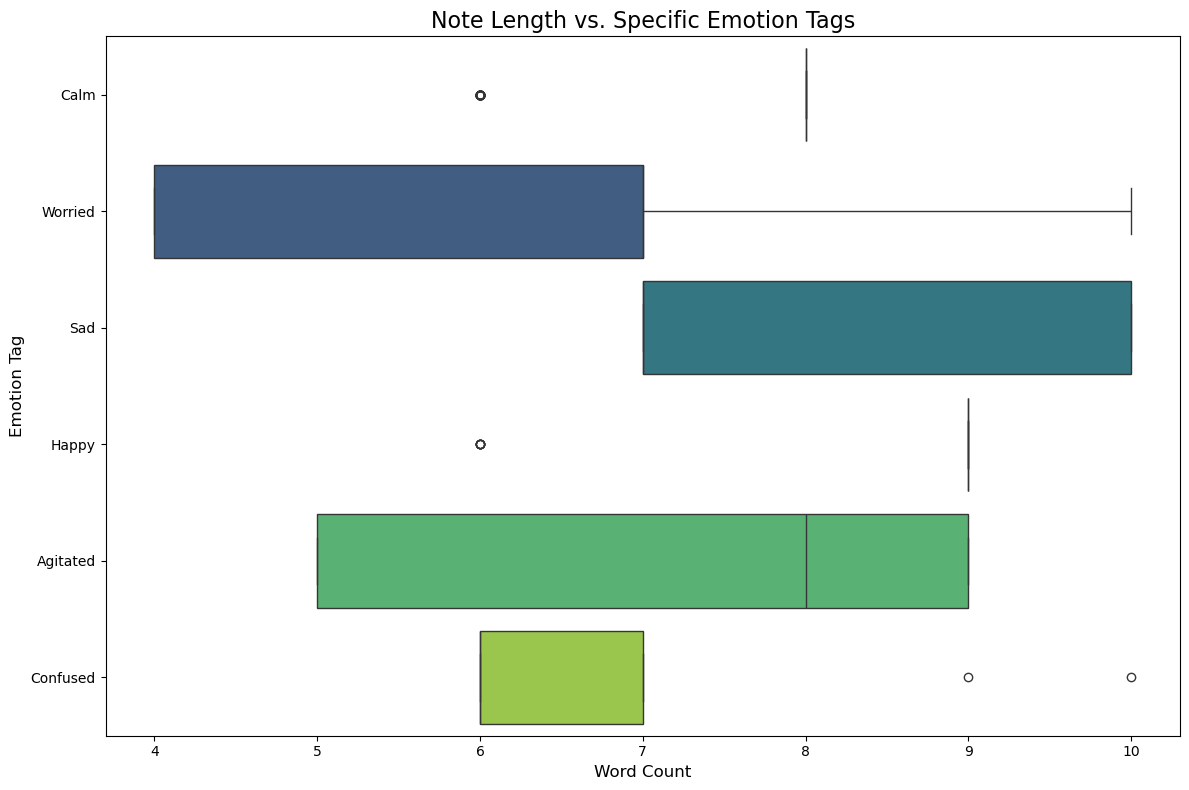

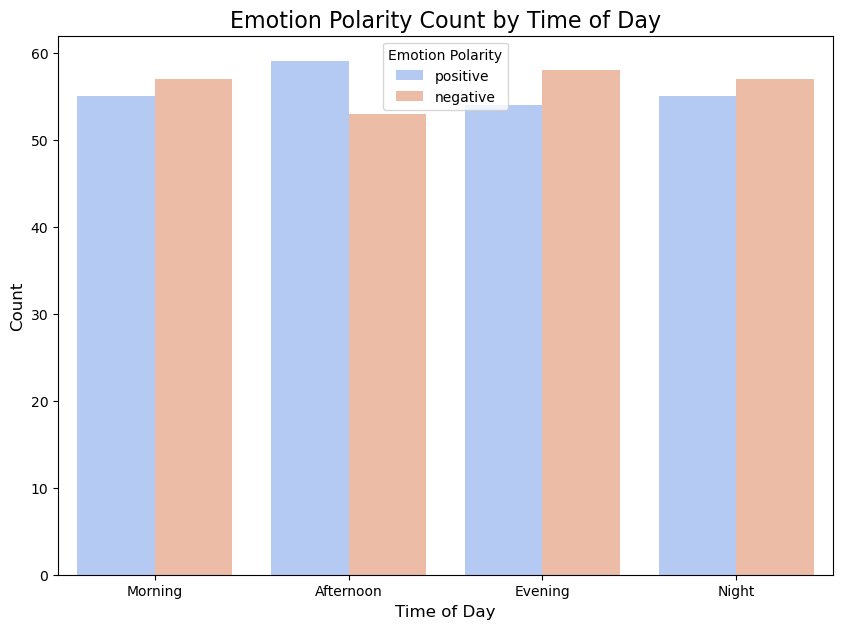

In [16]:
# ---  Cross insights ---
print("\n---: Finding Cross Insights ---")
# Do some emotions correlate with shorter/longer notes?
plt.figure(figsize=(12, 8))
sns.boxplot(x='word_count', y='emotionTags', data=df, order=df['emotionTags'].value_counts().index, palette='viridis')
plt.title('Note Length vs. Specific Emotion Tags', fontsize=16)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Emotion Tag', fontsize=12)
plt.tight_layout()
plt.savefig('emotion_vs_note_length.png')
print("Generated 'emotion_vs_note_length.png' showing relationship between emotions and note length.")

# Do caregivers report more negative emotions at certain times of day?
df['observationStart'] = pd.to_datetime(df['observationStart'])
df['hour'] = df['observationStart'].dt.hour

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='time_of_day', hue='emotionpolarity', order=['Morning', 'Afternoon', 'Evening', 'Night'], palette='coolwarm')
plt.title('Emotion Polarity Count by Time of Day', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Emotion Polarity')
plt.savefig('emotion_by_time_of_day.png')
print("Generated 'emotion_by_time_of_day.png' showing emotions across different times of day.")


print("\n--- Deep Profiling Complete. Pipeline Ready for Model Training ---")
